# V1.5 — Reusable BraTS Patient Loader

This notebook turns the V1 exploratory workflow into a reusable patient-loading pipeline for the BraTS-GLI dataset.

## Goals
- Load any BraTS-GLI patient by patient ID
- Load T1n, T1c, T2w, T2f, and segmentation volumes
- Validate that all volumes have matching shapes
- Verify segmentation labels
- Generate a compact patient summary
- Stack the four MRI modalities into a 4-channel volume
- Create reusable MRI and segmentation visualizations

---

## 1. Imports

In [2]:
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Dataset Path

In [3]:
DATA_DIR = Path(
    "../data/raw/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
)

print(DATA_DIR)

../data/raw/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData


## 3. Reusable Patient Loader

The loader expects the BraTS-GLI naming convention:

```text
<patient-id>-t1n.nii.gz
<patient-id>-t1c.nii.gz
<patient-id>-t2w.nii.gz
<patient-id>-t2f.nii.gz
<patient-id>-seg.nii.gz
```

In [4]:
def load_patient(patient_id):
    patient_dir = DATA_DIR / patient_id

    files = {
        "t1n": patient_dir / f"{patient_id}-t1n.nii.gz",
        "t1c": patient_dir / f"{patient_id}-t1c.nii.gz",
        "t2w": patient_dir / f"{patient_id}-t2w.nii.gz",
        "t2f": patient_dir / f"{patient_id}-t2f.nii.gz",
        "seg": patient_dir / f"{patient_id}-seg.nii.gz",
    }

    volumes = {}

    for modality, file_path in files.items():
        if not file_path.exists():
            raise FileNotFoundError(
                f"Missing {modality} file: {file_path}"
            )

        volumes[modality] = nib.load(file_path).get_fdata()

    return volumes

## 4. Load a Patient

In [5]:
patient = load_patient("BraTS-GLI-00442-000")
print(patient.keys())

dict_keys(['t1n', 't1c', 't2w', 't2f', 'seg'])


## 5. Inspect Volume Shapes

In [6]:
for modality, volume in patient.items():
    print(f"{modality}: {volume.shape}")

t1n: (240, 240, 155)
t1c: (240, 240, 155)
t2w: (240, 240, 155)
t2f: (240, 240, 155)
seg: (240, 240, 155)


## 6. Validate Patient Volumes

All five volumes should have the same spatial dimensions.

In [7]:
def validate_patient(patient):
    shapes = {
        modality: volume.shape
        for modality, volume in patient.items()
    }

    print("Shapes:")
    for modality, shape in shapes.items():
        print(f"  {modality}: {shape}")

    unique_shapes = set(shapes.values())

    if len(unique_shapes) != 1:
        raise ValueError(
            f"Volumes have inconsistent shapes: {shapes}"
        )

    print("\nAll volumes have matching shapes.")

In [8]:
validate_patient(patient)

Shapes:
  t1n: (240, 240, 155)
  t1c: (240, 240, 155)
  t2w: (240, 240, 155)
  t2f: (240, 240, 155)
  seg: (240, 240, 155)

All volumes have matching shapes.


## 7. Validate Segmentation Labels

BraTS-GLI uses the labels `0, 1, 2, 3` for this dataset.

In [9]:
def check_segmentation(patient):
    labels = np.unique(patient["seg"])

    print("Segmentation labels:", labels)

    if not np.all(np.isin(labels, [0, 1, 2, 3])):
        raise ValueError(
            f"Unexpected segmentation labels: {labels}"
        )

In [10]:
check_segmentation(patient)

Segmentation labels: [0. 1. 2. 3.]


## 8. Patient Summary

In [11]:
def patient_summary(patient_id):
    patient = load_patient(patient_id)

    print(f"Patient: {patient_id}")
    print("-" * 40)

    for modality, volume in patient.items():
        print(
            f"{modality:>4}: "
            f"shape={volume.shape}, "
            f"dtype={volume.dtype}"
        )

    print("\nSegmentation labels:")
    print(np.unique(patient["seg"]))

    print("\nTumor voxels:")
    print(np.sum(patient["seg"] > 0))

    return patient

In [12]:
patient = patient_summary("BraTS-GLI-00324-000")

Patient: BraTS-GLI-00324-000
----------------------------------------
 t1n: shape=(240, 240, 155), dtype=float64
 t1c: shape=(240, 240, 155), dtype=float64
 t2w: shape=(240, 240, 155), dtype=float64
 t2f: shape=(240, 240, 155), dtype=float64
 seg: shape=(240, 240, 155), dtype=float64

Segmentation labels:
[0. 1. 2. 3.]

Tumor voxels:
83418


---

## 9. Stack the Four MRI Modalities

The model will eventually receive the four MRI modalities as channels:

```text
Channel 0 → T1n
Channel 1 → T1c
Channel 2 → T2w
Channel 3 → T2f
```

The resulting shape is:

`(4, H, W, D)`

In [13]:
mri = np.stack(
    [
        patient["t1n"],
        patient["t1c"],
        patient["t2w"],
        patient["t2f"],
    ],
    axis=0
)

print("MRI shape:", mri.shape)

MRI shape: (4, 240, 240, 155)


In [18]:
for i, modality in enumerate(["t1n", "t1c", "t2w", "t2f"]):
    print(f"Channel {i}: {modality}, shape={mri[i].shape}")

Channel 0: t1n, shape=(240, 240, 155)
Channel 1: t1c, shape=(240, 240, 155)
Channel 2: t2w, shape=(240, 240, 155)
Channel 3: t2f, shape=(240, 240, 155)


## 10. Reusable MRI Visualization

In [14]:
def show_modalities(patient, slice_idx):
    modalities = ["t1n", "t1c", "t2w", "t2f"]

    fig, axes = plt.subplots(
        2, 2,
        figsize=(10, 10)
    )

    for ax, modality in zip(axes.ravel(), modalities):
        ax.imshow(
            patient[modality][:, :, slice_idx].T,
            cmap="gray",
            origin="lower"
        )

        ax.set_title(
            f"{modality.upper()} — Slice {slice_idx}"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

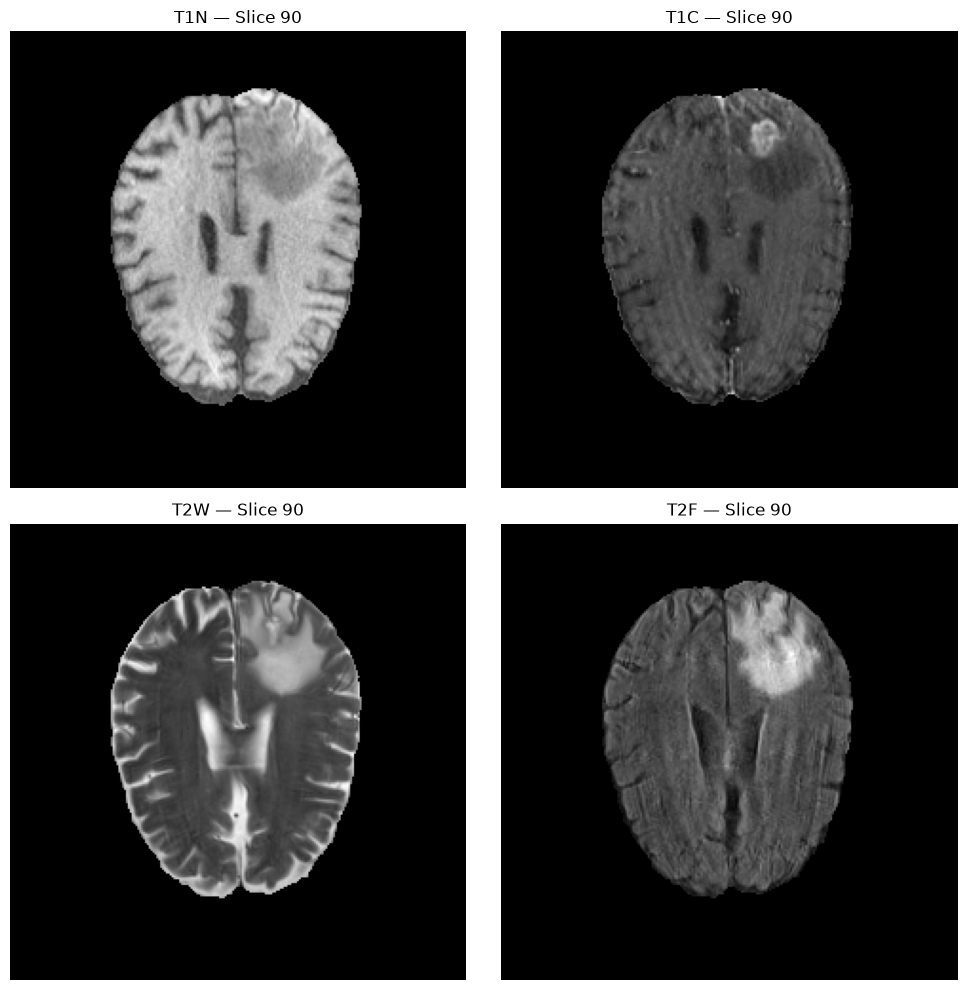

In [15]:
show_modalities(patient, 90)

## 11. Reusable Segmentation Visualization

In [16]:
def show_segmentation(patient, slice_idx):
    mri = patient["t2f"][:, :, slice_idx]
    seg = patient["seg"][:, :, slice_idx]

    plt.figure(figsize=(7, 7))

    plt.imshow(
        mri.T,
        cmap="gray",
        origin="lower"
    )

    plt.imshow(
        np.ma.masked_where(
            seg.T == 0,
            seg.T
        ),
        alpha=0.5,
        origin="lower"
    )

    plt.title(
        f"T2-FLAIR + Segmentation — Slice {slice_idx}"
    )

    plt.axis("off")
    plt.show()

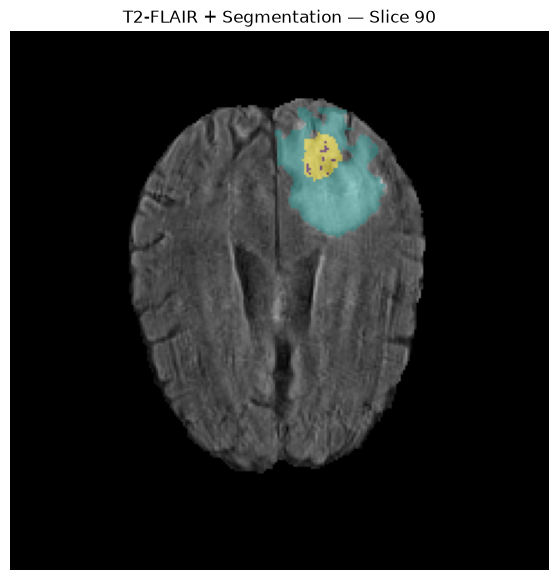

In [17]:
show_segmentation(patient, 90)